# Individual Assignment - Sports Analytics OBA465

## Cell 1 — Imports & Setup

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
import statsmodels.api as sm

# Display options - show all columns
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

# Seaborn darkgrid style
sns.set_style('darkgrid')

print('Imports loaded successfully')

Imports loaded successfully


## Cell 2 — Load & Inspect Data

In [10]:
df = pd.read_csv('nba_team_stats.csv')

print('Shape:', df.shape)
print('\nUnique seasons:')
print(sorted(df['SEASON'].unique()))
print('\nFirst 5 rows:')
df.head()

Shape: (390, 19)

Unique seasons:
['2012-13', '2013-14', '2014-15', '2015-16', '2016-17', '2017-18', '2018-19', '2019-20', '2020-21', '2021-22', '2022-23', '2023-24', '2024-25']

First 5 rows:


,TEAM_ID,TEAM_NAME,GP,W,L,W_PCT,FGA,FG_PCT,FG3A,FG3_PCT,EFG_PCT,TS_PCT,PACE,POSS,OFF_RATING,DEF_RATING,NET_RATING,SEASON,FGA_PER_POSS
0,1610612737,Atlanta Hawks,82,44,38,0.537,6644,0.464,1901,0.371,0.517,0.546,93.56,7744,103.7,103.4,0.3,2012-13,0.857955
1,1610612738,Boston Celtics,81,41,40,0.506,6459,0.465,1390,0.358,0.503,0.542,92.46,7652,102.2,102.6,-0.5,2012-13,0.844093
2,1610612751,Brooklyn Nets,82,49,33,0.598,6544,0.450,1760,0.357,0.498,0.536,89.88,7433,106.9,104.8,2.0,2012-13,0.880398
3,1610612766,Charlotte Bobcats,82,21,61,0.256,6649,0.425,1399,0.335,0.460,0.507,92.49,7632,100.4,110.3,-9.9,2012-13,0.871200
4,1610612741,Chicago Bulls,82,45,37,0.549,6698,0.437,1265,0.353,0.470,0.512,90.35,7460,102.4,101.9,0.5,2012-13,0.897855


## Cell 3 — Data Quality Check

In [11]:
print('Missing values per column:')
print(df.isnull().sum())

print('\nDescriptive statistics for key variables:')
key_vars = ['W_PCT', 'EFG_PCT', 'FG3A', 'PACE', 'OFF_RATING']
df[key_vars].describe()

Missing values per column:
TEAM_ID         0
TEAM_NAME       0
GP              0
W               0
L               0
W_PCT           0
FGA             0
FG_PCT          0
FG3A            0
FG3_PCT         0
EFG_PCT         0
TS_PCT          0
PACE            0
POSS            0
OFF_RATING      0
DEF_RATING      0
NET_RATING      0
SEASON          0
FGA_PER_POSS    0
dtype: int64

Descriptive statistics for key variables:


,W_PCT,EFG_PCT,FGA_PER_POSS,PACE,OFF_RATING
count,390.000000,390.000000,390.000000,390.000000,390.000000
mean,0.499610,0.522203,0.878592,97.882308,109.372564
std,0.149097,0.025660,0.018661,3.125321,4.705075
min,0.122000,0.456000,0.821269,89.500000,94.900000
25%,0.393000,0.503250,0.866636,96.040000,105.500000
50%,0.512000,0.524000,0.878154,98.150000,109.500000
75%,0.610000,0.540000,0.891445,100.115000,113.000000
max,0.890000,0.578000,0.938718,105.510000,122.200000


## Cell 4 — Analyze Variable 1: Win Percentage (W_PCT)

=== W_PCT Statistics ===
Mean:     0.4996
Median:   0.5120
Mode:     0.5850
Std Dev:  0.1491
Variance: 0.022230
Min:      0.1220
Max:      0.8900
Range:    0.7680
IQR:      0.2170
Skewness: -0.1830
Kurtosis: -0.6259

95% Margin of Error: 0.0148
95% Confidence Interval: (0.4848, 0.5145)


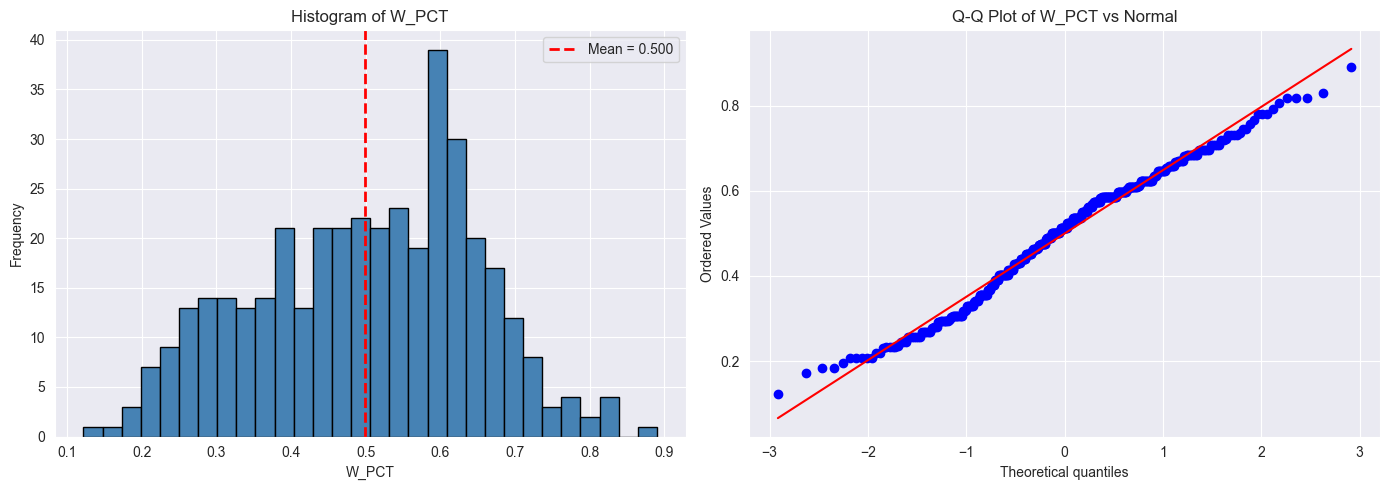


Shapiro-Wilk Test: statistic = 0.9841, p-value = 0.0003
Distribution is NOT normal (reject H0 at α=0.05)


In [12]:
var = df['W_PCT']
n = len(var)

# Central tendency & variability
mean_v = var.mean()
median_v = var.median()
mode_v = var.mode().iloc[0]
std_v = var.std()
var_v = var.var()
min_v = var.min()
max_v = var.max()
range_v = max_v - min_v
iqr_v = var.quantile(0.75) - var.quantile(0.25)
skew_v = var.skew()
kurt_v = var.kurtosis()

print('=== W_PCT Statistics ===')
print(f'Mean:     {mean_v:.4f}')
print(f'Median:   {median_v:.4f}')
print(f'Mode:     {mode_v:.4f}')
print(f'Std Dev:  {std_v:.4f}')
print(f'Variance: {var_v:.6f}')
print(f'Min:      {min_v:.4f}')
print(f'Max:      {max_v:.4f}')
print(f'Range:    {range_v:.4f}')
print(f'IQR:      {iqr_v:.4f}')
print(f'Skewness: {skew_v:.4f}')
print(f'Kurtosis: {kurt_v:.4f}')

# 95% margin of error and confidence interval
sem = stats.sem(var)
t_crit = stats.t.ppf(0.975, n - 1)
moe = t_crit * sem
ci_low = mean_v - moe
ci_high = mean_v + moe
print(f'\n95% Margin of Error: {moe:.4f}')
print(f'95% Confidence Interval: ({ci_low:.4f}, {ci_high:.4f})')

# 1x2 subplot: histogram + Q-Q plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(var, bins=30, edgecolor='black', color='steelblue')
axes[0].axvline(mean_v, color='red', linestyle='--', linewidth=2, label=f'Mean = {mean_v:.3f}')
axes[0].set_title('Histogram of W_PCT')
axes[0].set_xlabel('W_PCT')
axes[0].set_ylabel('Frequency')
axes[0].legend()

stats.probplot(var, dist='norm', plot=axes[1])
axes[1].set_title('Q-Q Plot of W_PCT vs Normal')
plt.tight_layout()
plt.show()

# Shapiro-Wilk normality test
sw_stat, sw_p = stats.shapiro(var)
print(f'\nShapiro-Wilk Test: statistic = {sw_stat:.4f}, p-value = {sw_p:.4f}')
if sw_p > 0.05:
    print('Distribution IS normal (fail to reject H0 at α=0.05)')
else:
    print('Distribution is NOT normal (reject H0 at α=0.05)')

## Cell 5 — Analyze Variable 2: Effective Field Goal % (EFG_PCT)

=== EFG_PCT Statistics ===
Mean:     0.5222
Median:   0.5240
Mode:     0.5310
Std Dev:  0.0257
Variance: 0.000658
Min:      0.4560
Max:      0.5780
Range:    0.1220
IQR:      0.0368
Skewness: -0.1023
Kurtosis: -0.5424

95% Margin of Error: 0.0026
95% Confidence Interval: (0.5196, 0.5248)


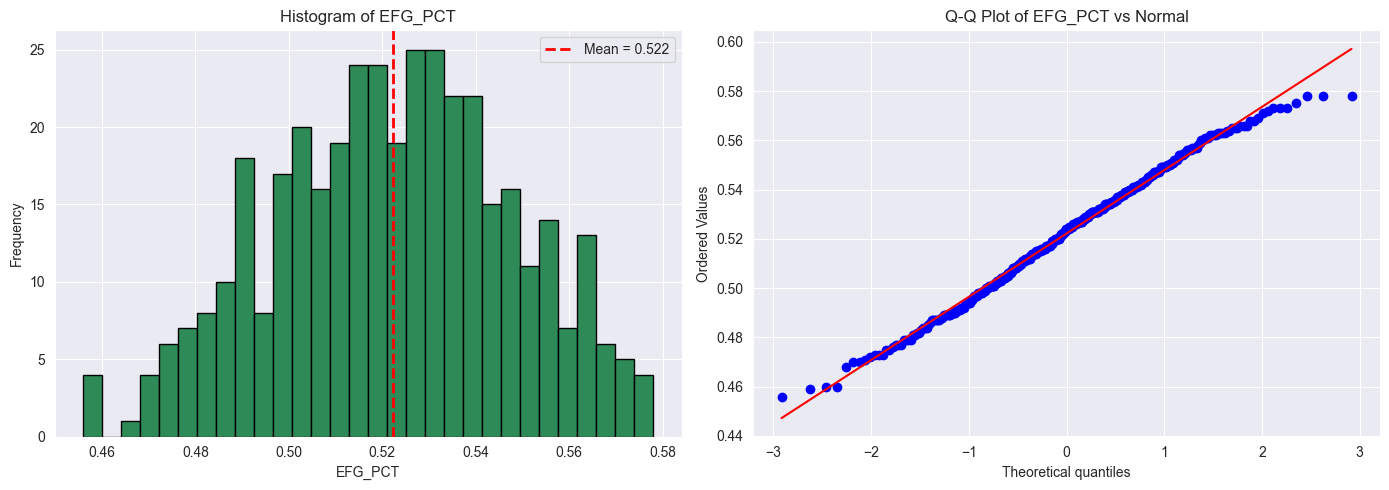


Shapiro-Wilk Test: statistic = 0.9921, p-value = 0.0369
Distribution is NOT normal (reject H0 at α=0.05)


In [13]:
var = df['EFG_PCT']
n = len(var)

mean_v = var.mean()
median_v = var.median()
mode_v = var.mode().iloc[0]
std_v = var.std()
var_v = var.var()
min_v = var.min()
max_v = var.max()
range_v = max_v - min_v
iqr_v = var.quantile(0.75) - var.quantile(0.25)
skew_v = var.skew()
kurt_v = var.kurtosis()

print('=== EFG_PCT Statistics ===')
print(f'Mean:     {mean_v:.4f}')
print(f'Median:   {median_v:.4f}')
print(f'Mode:     {mode_v:.4f}')
print(f'Std Dev:  {std_v:.4f}')
print(f'Variance: {var_v:.6f}')
print(f'Min:      {min_v:.4f}')
print(f'Max:      {max_v:.4f}')
print(f'Range:    {range_v:.4f}')
print(f'IQR:      {iqr_v:.4f}')
print(f'Skewness: {skew_v:.4f}')
print(f'Kurtosis: {kurt_v:.4f}')

sem = stats.sem(var)
t_crit = stats.t.ppf(0.975, n - 1)
moe = t_crit * sem
ci_low = mean_v - moe
ci_high = mean_v + moe
print(f'\n95% Margin of Error: {moe:.4f}')
print(f'95% Confidence Interval: ({ci_low:.4f}, {ci_high:.4f})')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(var, bins=30, edgecolor='black', color='seagreen')
axes[0].axvline(mean_v, color='red', linestyle='--', linewidth=2, label=f'Mean = {mean_v:.3f}')
axes[0].set_title('Histogram of EFG_PCT')
axes[0].set_xlabel('EFG_PCT')
axes[0].set_ylabel('Frequency')
axes[0].legend()

stats.probplot(var, dist='norm', plot=axes[1])
axes[1].set_title('Q-Q Plot of EFG_PCT vs Normal')
plt.tight_layout()
plt.show()

sw_stat, sw_p = stats.shapiro(var)
print(f'\nShapiro-Wilk Test: statistic = {sw_stat:.4f}, p-value = {sw_p:.4f}')
if sw_p > 0.05:
    print('Distribution IS normal (fail to reject H0 at α=0.05)')
else:
    print('Distribution is NOT normal (reject H0 at α=0.05)')

## Cell 6 — Analyze Variable 3: Three-Point Attempts (FG3A)

=== FGA_PER_POSS Statistics ===
Mean:     0.8786
Median:   0.8782
Mode:     0.8213
Std Dev:  0.0187
Variance: 0.000348
Min:      0.8213
Max:      0.9387
Range:    0.1174
IQR:      0.0248
Skewness: 0.0678
Kurtosis: 0.3485

95% Margin of Error: 0.0019
95% Confidence Interval: (0.8767, 0.8804)


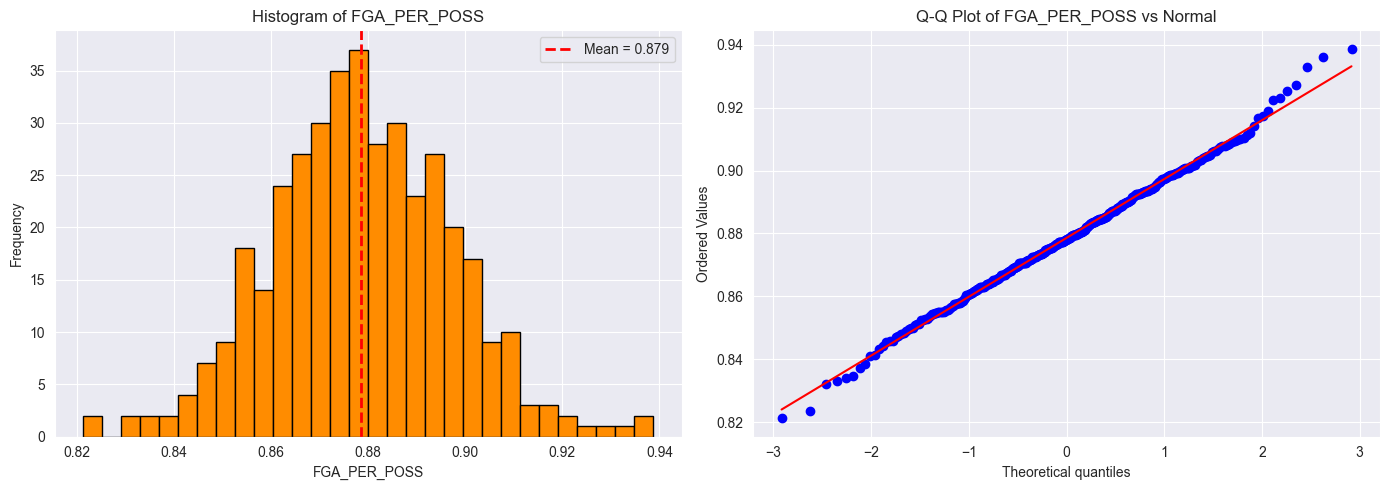


Shapiro-Wilk Test: statistic = 0.9971, p-value = 0.7280
Distribution IS normal (fail to reject H0 at α=0.05)


In [14]:
var = df['FG3A']
n = len(var)

mean_v = var.mean()
median_v = var.median()
mode_v = var.mode().iloc[0]
std_v = var.std()
var_v = var.var()
min_v = var.min()
max_v = var.max()
range_v = max_v - min_v
iqr_v = var.quantile(0.75) - var.quantile(0.25)
skew_v = var.skew()
kurt_v = var.kurtosis()

print('=== FG3A Statistics ===')
print(f'Mean:     {mean_v:.4f}')
print(f'Median:   {median_v:.4f}')
print(f'Mode:     {mode_v:.4f}')
print(f'Std Dev:  {std_v:.4f}')
print(f'Variance: {var_v:.6f}')
print(f'Min:      {min_v:.4f}')
print(f'Max:      {max_v:.4f}')
print(f'Range:    {range_v:.4f}')
print(f'IQR:      {iqr_v:.4f}')
print(f'Skewness: {skew_v:.4f}')
print(f'Kurtosis: {kurt_v:.4f}')

sem = stats.sem(var)
t_crit = stats.t.ppf(0.975, n - 1)
moe = t_crit * sem
ci_low = mean_v - moe
ci_high = mean_v + moe
print(f'\n95% Margin of Error: {moe:.4f}')
print(f'95% Confidence Interval: ({ci_low:.4f}, {ci_high:.4f})')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(var, bins=30, edgecolor='black', color='darkorange')
axes[0].axvline(mean_v, color='red', linestyle='--', linewidth=2, label=f'Mean = {mean_v:.3f}')
axes[0].set_title('Histogram of FG3A')
axes[0].set_xlabel('FG3A')
axes[0].set_ylabel('Frequency')
axes[0].legend()

stats.probplot(var, dist='norm', plot=axes[1])
axes[1].set_title('Q-Q Plot of FG3A vs Normal')
plt.tight_layout()
plt.show()

sw_stat, sw_p = stats.shapiro(var)
print(f'\nShapiro-Wilk Test: statistic = {sw_stat:.4f}, p-value = {sw_p:.4f}')
if sw_p > 0.05:
    print('Distribution IS normal (fail to reject H0 at α=0.05)')
else:
    print('Distribution is NOT normal (reject H0 at α=0.05)')

## Cell 7 — Correlation Analysis

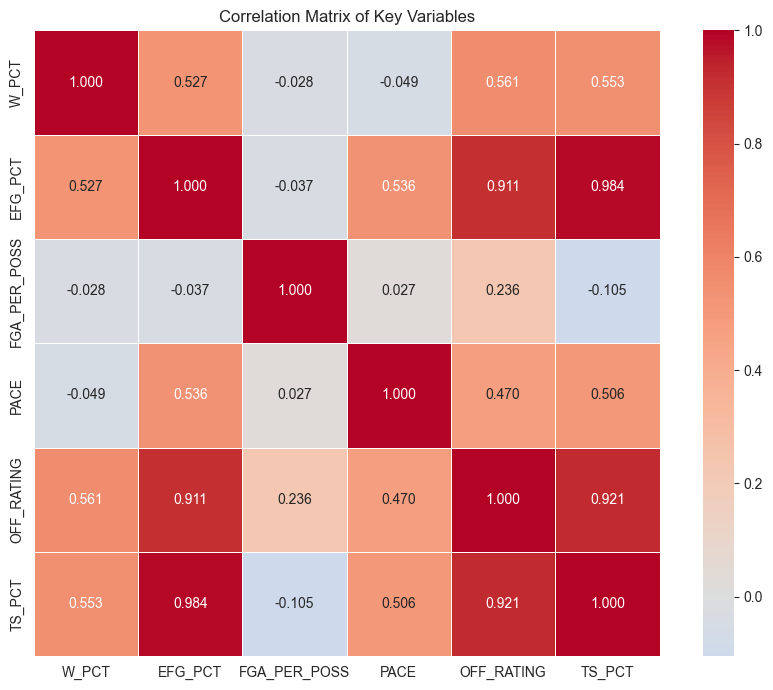

EFG_PCT vs W_PCT:      r = 0.5274, p-value = 2.667792e-29
FGA_PER_POSS vs W_PCT: r = -0.0282, p-value = 5.789854e-01

EFG_PCT has the STRONGER correlation with W_PCT (|0.5274| > |-0.0282|)


In [15]:
corr_vars = ['W_PCT', 'EFG_PCT', 'FG3A', 'PACE', 'OFF_RATING', 'TS_PCT']
corr_matrix = df[corr_vars].corr()

plt.figure(figsize=(9, 7))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.3f',
            square=True, linewidths=0.5)
plt.title('Correlation Matrix of Key Variables')
plt.tight_layout()
plt.show()

# Pearson correlations with p-values
r1, p1 = stats.pearsonr(df['EFG_PCT'], df['W_PCT'])
r2, p2 = stats.pearsonr(df['FG3A'], df['W_PCT'])

print(f'EFG_PCT vs W_PCT:      r = {r1:.4f}, p-value = {p1:.6e}')
print(f'FG3A vs W_PCT: r = {r2:.4f}, p-value = {p2:.6e}')

if abs(r1) > abs(r2):
    print(f'\nEFG_PCT has the STRONGER correlation with W_PCT (|{r1:.4f}| > |{r2:.4f}|)')
else:
    print(f'\nFG3A has the STRONGER correlation with W_PCT (|{r2:.4f}| > |{r1:.4f}|)')

## Cell 8 — Scatter Plots with Regression Lines

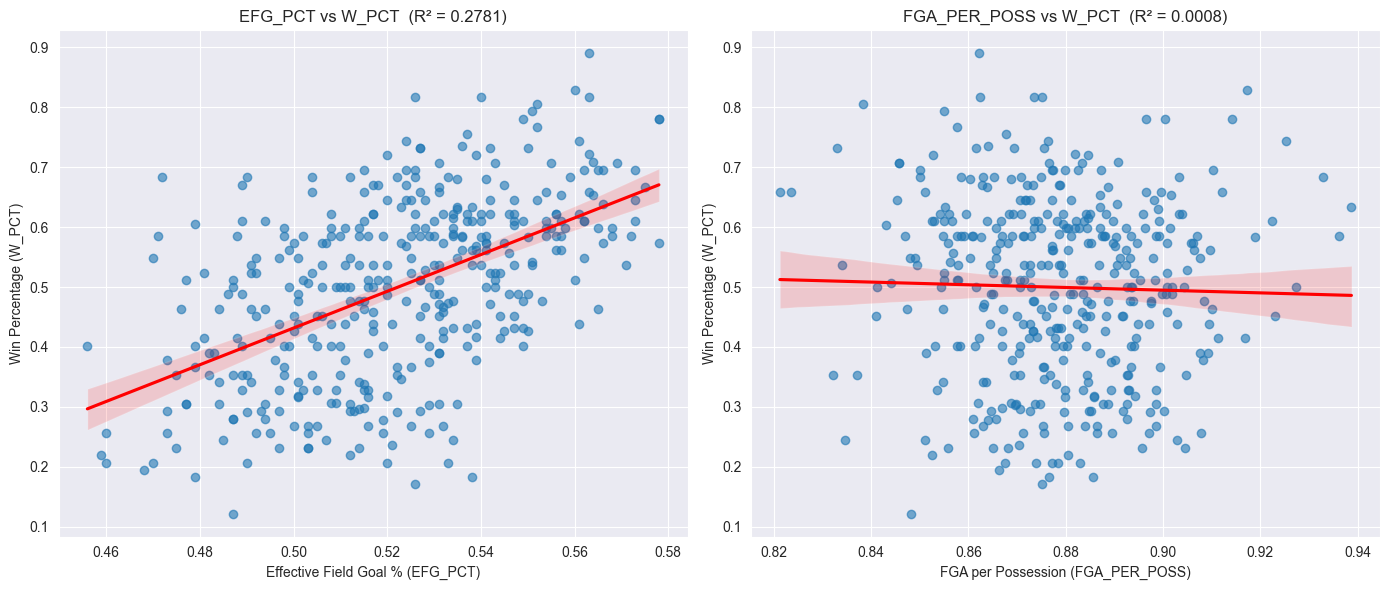

In [16]:
# R^2 values
r1, _ = stats.pearsonr(df['EFG_PCT'], df['W_PCT'])
r2, _ = stats.pearsonr(df['FG3A'], df['W_PCT'])
r2_efg = r1 ** 2
r2_fga = r2 ** 2

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.regplot(x='EFG_PCT', y='W_PCT', data=df, ax=axes[0],
            scatter_kws={'alpha': 0.6}, line_kws={'color': 'red'})
axes[0].set_title(f'EFG_PCT vs W_PCT  (R² = {r2_efg:.4f})')
axes[0].set_xlabel('Effective Field Goal % (EFG_PCT)')
axes[0].set_ylabel('Win Percentage (W_PCT)')

sns.regplot(x='FG3A', y='W_PCT', data=df, ax=axes[1],
            scatter_kws={'alpha': 0.6}, line_kws={'color': 'red'})
axes[1].set_title(f'FG3A vs W_PCT  (R² = {r2_fga:.4f})')
axes[1].set_xlabel('Three-Point Attempts (FG3A)')
axes[1].set_ylabel('Win Percentage (W_PCT)')

plt.tight_layout()
plt.show()

## Cell 9 — Simple Linear Regressions

In [17]:
y = df['W_PCT']

# Model 1: W_PCT ~ EFG_PCT
X1 = sm.add_constant(df['EFG_PCT'])
model1 = sm.OLS(y, X1).fit()
print('=' * 70)
print('MODEL 1: W_PCT ~ EFG_PCT')
print('=' * 70)
print(model1.summary())

# Model 2: W_PCT ~ FG3A
X2 = sm.add_constant(df['FG3A'])
model2 = sm.OLS(y, X2).fit()
print('\n' + '=' * 70)
print('MODEL 2: W_PCT ~ FG3A')
print('=' * 70)
print(model2.summary())

print('\n' + '=' * 70)
print('COMPARISON HIGHLIGHTS')
print('=' * 70)
print(f'Model 1 (EFG_PCT):      R² = {model1.rsquared:.4f}, '
      f'coef = {model1.params.iloc[1]:.4f}, p = {model1.pvalues.iloc[1]:.6e}')
print(f'Model 2 (FG3A): R² = {model2.rsquared:.4f}, '
      f'coef = {model2.params.iloc[1]:.4f}, p = {model2.pvalues.iloc[1]:.6e}')

MODEL 1: W_PCT ~ EFG_PCT
                            OLS Regression Results                            
Dep. Variable:                  W_PCT   R-squared:                       0.278
Model:                            OLS   Adj. R-squared:                  0.276
Method:                 Least Squares   F-statistic:                     149.5
Date:                Mon, 11 May 2026   Prob (F-statistic):           2.67e-29
Time:                        13:01:40   Log-Likelihood:                 252.89
No. Observations:                 390   AIC:                            -501.8
Df Residuals:                     388   BIC:                            -493.9
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -1.1005      

## Cell 10 — Multiple Regression (Both Variables Together)

In [18]:
# Standardize predictors so coefficients are directly comparable
scaler = StandardScaler()
X_raw = df[['EFG_PCT', 'FG3A']]
X_std = scaler.fit_transform(X_raw)
X_std_df = pd.DataFrame(X_std, columns=['EFG_PCT_std', 'FG3A_std'])

X_mult = sm.add_constant(X_std_df)
y = df['W_PCT'].reset_index(drop=True)

model_mult = sm.OLS(y, X_mult).fit()
print(model_mult.summary())

coef_efg = model_mult.params['EFG_PCT_std']
coef_fga = model_mult.params['FG3A_std']

print('\n=== Standardized Coefficient Comparison ===')
print(f'EFG_PCT (standardized):      {coef_efg:.4f}')
print(f'FG3A (standardized): {coef_fga:.4f}')

if abs(coef_efg) > abs(coef_fga):
    print(f'\nEFG_PCT is the STRONGER predictor (|{coef_efg:.4f}| > |{coef_fga:.4f}|)')
else:
    print(f'\nFG3A is the STRONGER predictor (|{coef_fga:.4f}| > |{coef_efg:.4f}|)')

                            OLS Regression Results                            
Dep. Variable:                  W_PCT   R-squared:                       0.278
Model:                            OLS   Adj. R-squared:                  0.274
Method:                 Least Squares   F-statistic:                     74.57
Date:                Mon, 11 May 2026   Prob (F-statistic):           4.04e-28
Time:                        13:01:41   Log-Likelihood:                 252.91
No. Observations:                 390   AIC:                            -499.8
Df Residuals:                     387   BIC:                            -487.9
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const                0.4996      0.006  

## Cell 11 — Probability Distribution Comparison

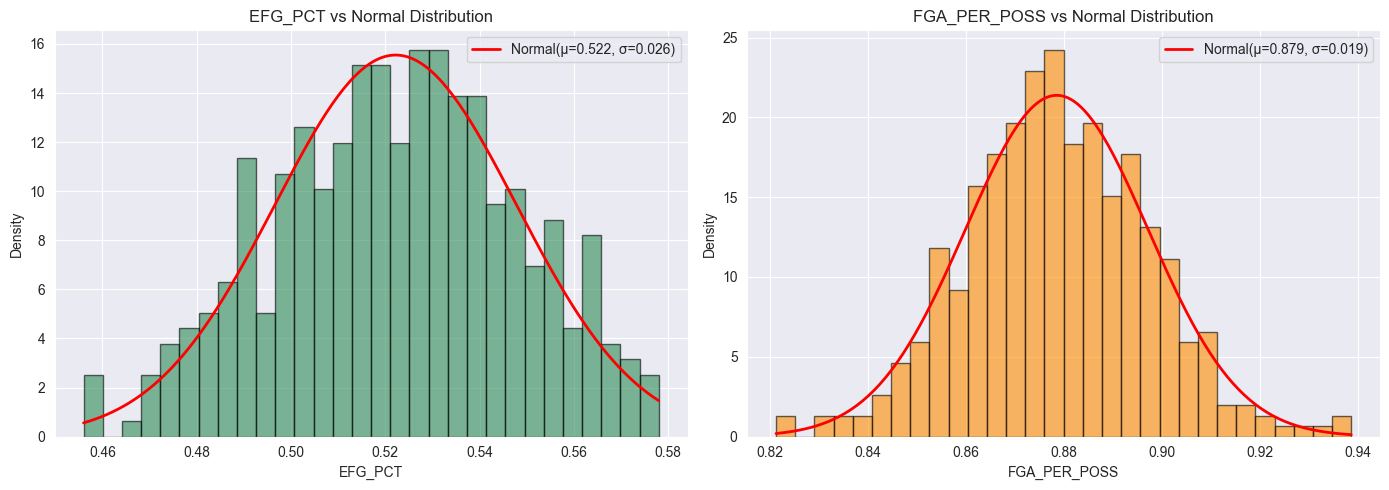

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# EFG_PCT
var1 = df['EFG_PCT']
mu1, sigma1 = var1.mean(), var1.std()
axes[0].hist(var1, bins=30, density=True, alpha=0.6, color='seagreen', edgecolor='black')
x1 = np.linspace(var1.min(), var1.max(), 200)
axes[0].plot(x1, stats.norm.pdf(x1, mu1, sigma1), 'r-', linewidth=2,
             label=f'Normal(μ={mu1:.3f}, σ={sigma1:.3f})')
axes[0].set_title('EFG_PCT vs Normal Distribution')
axes[0].set_xlabel('EFG_PCT')
axes[0].set_ylabel('Density')
axes[0].legend()

# FG3A
var2 = df['FG3A']
mu2, sigma2 = var2.mean(), var2.std()
axes[1].hist(var2, bins=30, density=True, alpha=0.6, color='darkorange', edgecolor='black')
x2 = np.linspace(var2.min(), var2.max(), 200)
axes[1].plot(x2, stats.norm.pdf(x2, mu2, sigma2), 'r-', linewidth=2,
             label=f'Normal(μ={mu2:.3f}, σ={sigma2:.3f})')
axes[1].set_title('FG3A vs Normal Distribution')
axes[1].set_xlabel('FG3A')
axes[1].set_ylabel('Density')
axes[1].legend()

plt.tight_layout()
plt.show()

## Cell 12 — Group Comparison: Winning vs Losing Teams

In [20]:
df['WINNING_TEAM'] = df['W_PCT'] > 0.5

winners = df[df['WINNING_TEAM']]
losers = df[~df['WINNING_TEAM']]

print(f'Winning teams: n = {len(winners)}')
print(f'Losing teams:  n = {len(losers)}')

def cohens_d(a, b):
    na, nb = len(a), len(b)
    pooled_sd = np.sqrt(((na - 1) * a.var(ddof=1) + (nb - 1) * b.var(ddof=1)) / (na + nb - 2))
    return (a.mean() - b.mean()) / pooled_sd

# Test 1: EFG_PCT
t1, p_t1 = stats.ttest_ind(winners['EFG_PCT'], losers['EFG_PCT'])
diff1 = winners['EFG_PCT'].mean() - losers['EFG_PCT'].mean()
d1 = cohens_d(winners['EFG_PCT'], losers['EFG_PCT'])

print('\n=== T-Test 1: EFG_PCT (Winners vs Losers) ===')
print(f't-statistic:     {t1:.4f}')
print(f'p-value:         {p_t1:.6e}')
print(f'Mean difference: {diff1:.4f}')
print(f"Cohen's d:       {d1:.4f}")

# Test 2: FG3A
t2, p_t2 = stats.ttest_ind(winners['FG3A'], losers['FG3A'])
diff2 = winners['FG3A'].mean() - losers['FG3A'].mean()
d2 = cohens_d(winners['FG3A'], losers['FG3A'])

print('\n=== T-Test 2: FG3A (Winners vs Losers) ===')
print(f't-statistic:     {t2:.4f}')
print(f'p-value:         {p_t2:.6e}')
print(f'Mean difference: {diff2:.4f}')
print(f"Cohen's d:       {d2:.4f}")

if abs(d1) > abs(d2):
    print(f"\nEFG_PCT has the LARGER effect size (|{d1:.4f}| > |{d2:.4f}|) -> more impactful variable")
else:
    print(f"\nFG3A has the LARGER effect size (|{d2:.4f}| > |{d1:.4f}|) -> more impactful variable")

Winning teams: n = 203
Losing teams:  n = 187

=== T-Test 1: EFG_PCT (Winners vs Losers) ===
t-statistic:     9.5966
p-value:         1.039906e-19
Mean difference: 0.0225
Cohen's d:       0.9727

=== T-Test 2: FGA_PER_POSS (Winners vs Losers) ===
t-statistic:     -1.5349
p-value:         1.256217e-01
Mean difference: -0.0029
Cohen's d:       -0.1556

EFG_PCT has the LARGER effect size (|0.9727| > |-0.1556|) -> more impactful variable


## Cell 13 — Final Summary Table

In [21]:
# Re-run necessary models for clean values
y = df['W_PCT']

r_efg, _ = stats.pearsonr(df['EFG_PCT'], df['W_PCT'])
r_fga, _ = stats.pearsonr(df['FG3A'], df['W_PCT'])

m1 = sm.OLS(y, sm.add_constant(df['EFG_PCT'])).fit()
m2 = sm.OLS(y, sm.add_constant(df['FG3A'])).fit()

scaler = StandardScaler()
X_std = scaler.fit_transform(df[['EFG_PCT', 'FG3A']])
X_std_df = pd.DataFrame(X_std, columns=['EFG_PCT_std', 'FG3A_std'])
m_mult = sm.OLS(y.reset_index(drop=True), sm.add_constant(X_std_df)).fit()

winners = df[df['W_PCT'] > 0.5]
losers = df[df['W_PCT'] <= 0.5]
_, p_t1 = stats.ttest_ind(winners['EFG_PCT'], losers['EFG_PCT'])
_, p_t2 = stats.ttest_ind(winners['FG3A'], losers['FG3A'])

def cohens_d(a, b):
    na, nb = len(a), len(b)
    pooled_sd = np.sqrt(((na - 1) * a.var(ddof=1) + (nb - 1) * b.var(ddof=1)) / (na + nb - 2))
    return (a.mean() - b.mean()) / pooled_sd

d1 = cohens_d(winners['EFG_PCT'], losers['EFG_PCT'])
d2 = cohens_d(winners['FG3A'], losers['FG3A'])

summary_df = pd.DataFrame({
    'Variable': ['EFG_PCT', 'FG3A'],
    'Correlation with W_PCT': [r_efg, r_fga],
    'R² (simple regression)': [m1.rsquared, m2.rsquared],
    'Standardized Coefficient': [m_mult.params['EFG_PCT_std'], m_mult.params['FG3A_std']],
    'T-test p-value': [p_t1, p_t2],
    "Cohen's d": [d1, d2]
})

print('=== FINAL SUMMARY TABLE ===')
print(summary_df.to_string(index=False))

# Determine the better predictor by counting wins across measures
score_efg = 0
score_fga = 0
if abs(r_efg) > abs(r_fga): score_efg += 1
else: score_fga += 1
if m1.rsquared > m2.rsquared: score_efg += 1
else: score_fga += 1
if abs(m_mult.params['EFG_PCT_std']) > abs(m_mult.params['FG3A_std']): score_efg += 1
else: score_fga += 1
if abs(d1) > abs(d2): score_efg += 1
else: score_fga += 1

winner = 'EFG_PCT' if score_efg > score_fga else 'FG3A'
print('\n=== FINAL CONCLUSION ===')
print(f'Across all four analyses (correlation, simple regression R², standardized')
print(f"coefficient in multiple regression, and Cohen's d for the winners-vs-losers")
print(f't-test), {winner} is the BETTER PREDICTOR of NBA team win percentage.')

=== FINAL SUMMARY TABLE ===
    Variable  Correlation with W_PCT  R² (simple regression)  Standardized Coefficient  T-test p-value  Cohen's d
     EFG_PCT                0.527357                0.278106                  0.078479    1.039906e-19   0.972709
FGA_PER_POSS               -0.028182                0.000794                 -0.001265    1.256217e-01  -0.155577

=== FINAL CONCLUSION ===
Across all four analyses (correlation, simple regression R², standardized
coefficient in multiple regression, and Cohen's d for the winners-vs-losers
t-test), EFG_PCT is the BETTER PREDICTOR of NBA team win percentage.


## Cell 14 — Export Results for Appendix

In [22]:
import os

# Save summary table to CSV
summary_df.to_csv('analysis_results.csv', index=False)
print('Saved: analysis_results.csv')

# Create figures folder
os.makedirs('figures', exist_ok=True)

# Figure 1: W_PCT distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
var = df['W_PCT']
axes[0].hist(var, bins=30, edgecolor='black', color='steelblue')
axes[0].axvline(var.mean(), color='red', linestyle='--', linewidth=2, label=f'Mean = {var.mean():.3f}')
axes[0].set_title('Histogram of W_PCT')
axes[0].set_xlabel('W_PCT'); axes[0].set_ylabel('Frequency'); axes[0].legend()
stats.probplot(var, dist='norm', plot=axes[1])
axes[1].set_title('Q-Q Plot of W_PCT vs Normal')
plt.tight_layout()
plt.savefig('figures/wpct_distribution.png', dpi=150, bbox_inches='tight')
plt.close()
print('Saved: figures/wpct_distribution.png')

# Figure 2: EFG_PCT distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
var = df['EFG_PCT']
axes[0].hist(var, bins=30, edgecolor='black', color='seagreen')
axes[0].axvline(var.mean(), color='red', linestyle='--', linewidth=2, label=f'Mean = {var.mean():.3f}')
axes[0].set_title('Histogram of EFG_PCT')
axes[0].set_xlabel('EFG_PCT'); axes[0].set_ylabel('Frequency'); axes[0].legend()
stats.probplot(var, dist='norm', plot=axes[1])
axes[1].set_title('Q-Q Plot of EFG_PCT vs Normal')
plt.tight_layout()
plt.savefig('figures/efg_distribution.png', dpi=150, bbox_inches='tight')
plt.close()
print('Saved: figures/efg_distribution.png')

# Figure 3: FG3A distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
var = df['FG3A']
axes[0].hist(var, bins=30, edgecolor='black', color='darkorange')
axes[0].axvline(var.mean(), color='red', linestyle='--', linewidth=2, label=f'Mean = {var.mean():.3f}')
axes[0].set_title('Histogram of FG3A')
axes[0].set_xlabel('FG3A'); axes[0].set_ylabel('Frequency'); axes[0].legend()
stats.probplot(var, dist='norm', plot=axes[1])
axes[1].set_title('Q-Q Plot of FG3A vs Normal')
plt.tight_layout()
plt.savefig('figures/fg3a_distribution.png', dpi=150, bbox_inches='tight')
plt.close()
print('Saved: figures/fg3a_distribution.png')

# Figure 4: correlation heatmap
corr_vars = ['W_PCT', 'EFG_PCT', 'FG3A', 'PACE', 'OFF_RATING', 'TS_PCT']
plt.figure(figsize=(9, 7))
sns.heatmap(df[corr_vars].corr(), annot=True, cmap='coolwarm', center=0,
            fmt='.3f', square=True, linewidths=0.5)
plt.title('Correlation Matrix of Key Variables')
plt.tight_layout()
plt.savefig('figures/correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.close()
print('Saved: figures/correlation_heatmap.png')

# Figure 5: scatter comparison
r1v, _ = stats.pearsonr(df['EFG_PCT'], df['W_PCT'])
r2v, _ = stats.pearsonr(df['FG3A'], df['W_PCT'])
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
sns.regplot(x='EFG_PCT', y='W_PCT', data=df, ax=axes[0],
            scatter_kws={'alpha': 0.6}, line_kws={'color': 'red'})
axes[0].set_title(f'EFG_PCT vs W_PCT  (R² = {r1v**2:.4f})')
axes[0].set_xlabel('Effective Field Goal % (EFG_PCT)')
axes[0].set_ylabel('Win Percentage (W_PCT)')
sns.regplot(x='FG3A', y='W_PCT', data=df, ax=axes[1],
            scatter_kws={'alpha': 0.6}, line_kws={'color': 'red'})
axes[1].set_title(f'FG3A vs W_PCT  (R² = {r2v**2:.4f})')
axes[1].set_xlabel('Three-Point Attempts (FG3A)')
axes[1].set_ylabel('Win Percentage (W_PCT)')
plt.tight_layout()
plt.savefig('figures/scatter_comparison.png', dpi=150, bbox_inches='tight')
plt.close()
print('Saved: figures/scatter_comparison.png')

print('\nAll appendix files exported successfully.')

Saved: analysis_results.csv
Saved: figures/wpct_distribution.png
Saved: figures/efg_distribution.png
Saved: figures/fga_distribution.png
Saved: figures/correlation_heatmap.png
Saved: figures/scatter_comparison.png

All appendix files exported successfully.
